In [12]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:0000:01


In [13]:
import os
import math
import random
from pathlib import Path
from PIL import Image, ImageFilter, ImageEnhance

import cv2
import numpy as np
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision.transforms import InterpolationMode

import gc
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp


from transformers import SegformerForSemanticSegmentation

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# img_dir = Path("/kaggle/input/datasets/karmagames/wrinkles-dataset/images_wrinkles_preprocess/images_wrinkles_preprocess")
mask_dir = Path("/kaggle/input/datasets/karmagames/acne04-v2/clean_roi/clean_roi")
img_dir = Path("/kaggle/input/datasets/karmagames/acne04-v2/images_acne_preprocess/images_acne_preprocess")


IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

torch.backends.cudnn.benchmark = True
# os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [14]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


class RandomGamma:
    def __init__(self, gamma_range=(0.8, 1.25), p=0.5):
        self.gamma_range = gamma_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            gamma = random.uniform(*self.gamma_range)
            return TF.adjust_gamma(img, gamma)
        return img


class RandomGaussianBlur:
    def __init__(self, radius_range=(0.1, 0.8), p=0.2):
        self.radius_range = radius_range
        self.p = p

    def __call__(self, img):
        if random.random() < self.p:
            sigma = random.uniform(*self.radius_range)
            return TF.gaussian_blur(img, kernel_size=3, sigma=sigma)
        return img


class AcneSegDataset(Dataset):
    def __init__(
        self,
        image_paths,
        images_dir,
        masks_dir,
        image_size=256,
        train=True,
        return_path=False,
    ):
        self.image_paths = image_paths
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.image_size = image_size
        self.train = train
        self.return_path = return_path

        self.color_aug = transforms.Compose([
            transforms.ColorJitter(
                brightness=0.20,
                contrast=0.20,
                saturation=0.08,
                hue=0.015
            ),
            RandomGamma(gamma_range=(0.80, 1.25), p=0.50),
            RandomGaussianBlur(radius_range=(0.1, 0.8), p=0.20),
        ])

        self.normalize = transforms.Normalize(
            mean=(0.485, 0.456, 0.406),
            std=(0.229, 0.224, 0.225)
        )

    def __len__(self):
        return len(self.image_paths)

    def _get_image_path(self, img_item):
        img_item = Path(img_item)

        # якщо вже переданий повний шлях
        if img_item.exists():
            return img_item

        # якщо передане тільки ім'я файлу
        return self.images_dir / img_item.name

    def _get_mask_path(self, img_path):
        img_path = Path(img_path)
        mask_name = img_path.stem + ".png"
        return self.masks_dir / mask_name

    def __getitem__(self, idx):
        img_item = self.image_paths[idx]
        img_path = self._get_image_path(img_item)
        mask_path = self._get_mask_path(img_path)

        # image
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # mask
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
      
        # resize
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = cv2.resize(mask, (self.image_size, self.image_size), interpolation=cv2.INTER_NEAREST)

        # to PIL
        img = TF.to_pil_image(img)
        mask = TF.to_pil_image(mask)

        # geometric aug
        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
                mask = TF.hflip(mask)

            if random.random() < 0.15:
                img = TF.vflip(img)
                mask = TF.vflip(mask)

            angle = random.uniform(-10, 10)
            img = TF.rotate(img, angle, interpolation=InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST)

            img = self.color_aug(img)

        # to tensor
        img = TF.to_tensor(img)
        img = self.normalize(img)

        mask = TF.to_tensor(mask)
        mask = (mask > 0.5).float()

        if self.return_path:
            return img, mask, str(img_path)

        return img, mask



def denormalize(img, mean, std):
    """
    img: tensor [C,H,W]
    """
    img = img.clone()
    for c in range(img.shape[0]):
        img[c] = img[c] * std[c] + mean[c]
    return img

def show_batch_with_masks(loader):
    imgs, masks = next(iter(loader))

    imgs = imgs.cpu()
    masks = masks.cpu()

    B = imgs.shape[0]

    fig, axes = plt.subplots(2, B, figsize=(3 * B, 6))

    for i in range(B):

        img = denormalize(imgs[i], IMAGENET_MEAN, IMAGENET_STD)

        img = img.numpy().transpose(1, 2, 0)
        mask = masks[i, 0].numpy()

        img = np.clip(img, 0, 1)

        axes[0, i].imshow(img)
        axes[0, i].axis("off")

        axes[1, i].imshow(mask, cmap="gray")
        axes[1, i].axis("off")

    axes[0, B // 2].set_title("Top: Images | Bottom: Masks")

    plt.tight_layout()
    plt.show()


In [15]:
ROOT = "/kaggle/input/datasets/karmagames/acne04-v2/"
IMAGES_DIR = os.path.join(ROOT, "clean_roi/clean_roi")
MASKS_DIR = os.path.join(ROOT, "gt_masks/gt_masks")

valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


all_image_paths = []
for fname in sorted(os.listdir(IMAGES_DIR)):
    ext = Path(fname).suffix.lower()
    if ext not in valid_exts:
        continue

    img_path = os.path.join(IMAGES_DIR, fname)
    mask_path = os.path.join(MASKS_DIR, Path(fname).stem + ".png")

    if os.path.exists(mask_path):
        all_image_paths.append(img_path)

print(f"Found {len(all_image_paths)} image-mask pairs")

Found 1117 image-mask pairs


In [16]:
train_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

val_paths, test_paths = train_test_split(
    temp_paths,
    test_size=0.5,
    random_state=42,
    shuffle=True,
)

print("Train:", len(train_paths))
print("Val:", len(val_paths))
print("Test:", len(test_paths))

Train: 893
Val: 112
Test: 112


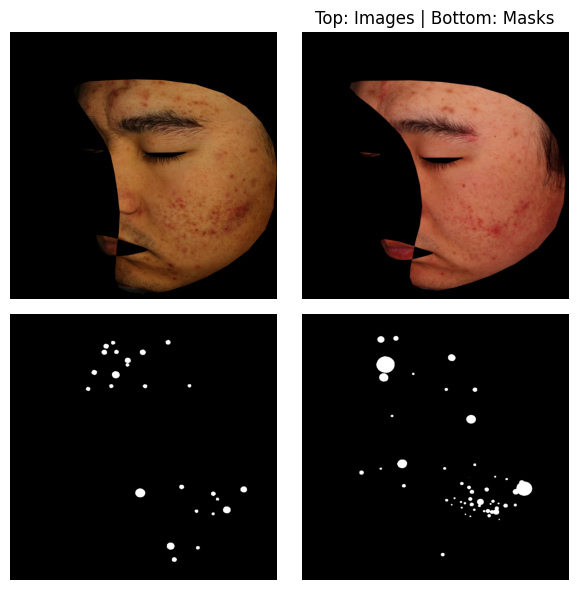

In [17]:
train_ds = AcneSegDataset(
    image_paths=train_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=1024,
    train=True,
)

val_ds = AcneSegDataset(
    image_paths=val_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=1024,
    train=False,
)

test_ds = AcneSegDataset(
    image_paths=test_paths,
    images_dir=IMAGES_DIR,
    masks_dir=MASKS_DIR,
    image_size=1024,
    train=False,
)

train_loader = DataLoader(
    train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

show_batch_with_masks(train_loader)

In [18]:

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, smooth=1.0):
    probs = torch.sigmoid(logits)

    probs = probs.view(probs.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (probs * targets).sum(dim=1)
    dice = (2.0 * intersection + smooth) / (
        probs.sum(dim=1) + targets.sum(dim=1) + smooth
    )

    return 1.0 - dice.mean()


def bce_dice_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)


def batch_iou_dice(logits, targets, threshold=0.5, eps=1e-8):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    intersection = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (preds.sum(dim=1) + targets.sum(dim=1) + eps)

    return iou.mean().item(), dice.mean().item()


def train_one_epoch(model, loader, optimizer, device, ep, epochs):
    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0
    
    pbar = tqdm(loader, desc=f"epoch {ep}/{epochs}", leave=False)

    for imgs, masks in pbar:
        imgs = imgs.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        loss.backward()
        optimizer.step()

        iou, dice = batch_iou_dice(logits.detach(), masks)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

    n = len(loader)
    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
    }


@torch.no_grad()
def validate_one_epoch(model, loader, device, threshold=0.5, eps=1e-8):
    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    # для глобальних метрик
    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        logits = model(imgs)
        loss = bce_dice_loss(logits, masks)

        # базові метрики
        iou, dice = batch_iou_dice(logits, masks)

        running_loss += loss.item()
        running_iou += iou
        running_dice += dice

        # ===== нове: pixel-level метрики =====
        probs = torch.sigmoid(logits)
        preds = (probs > threshold).float()

        tp = (preds * masks).sum().item()
        fp = (preds * (1 - masks)).sum().item()
        fn = ((1 - preds) * masks).sum().item()
        tn = ((1 - preds) * (1 - masks)).sum().item()

        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn

    n = len(loader)

    # ===== фінальні метрики =====
    accuracy = (total_tp + total_tn) / (total_tp + total_tn + total_fp + total_fn + eps)
    precision = total_tp / (total_tp + total_fp + eps)
    recall = total_tp / (total_tp + total_fn + eps)

    return {
        "loss": running_loss / n,
        "iou": running_iou / n,
        "dice": running_dice / n,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
    }


@torch.no_grad()
def predict_batch(model, loader, device, threshold=0.5):
    model.eval()
    imgs, masks = next(iter(loader))

    imgs = imgs.to(device)
    masks = masks.to(device)

    logits = model(imgs)
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()

    return imgs.cpu(), masks.cpu(), logits.cpu(), preds.cpu(), probs.cpu()


def single_iou_dice(logit, target, threshold=0.5, eps=1e-8):
    """
    logit: tensor [1, H, W] або [H, W]
    target: tensor [1, H, W] або [H, W]
    """
    if logit.ndim == 3:
        logit = logit.squeeze(0)
    if target.ndim == 3:
        target = target.squeeze(0)

    prob = torch.sigmoid(logit)
    pred = (prob > threshold).float()

    pred = pred.view(-1)
    target = target.view(-1)

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + eps) / (union + eps)
    dice = (2 * intersection + eps) / (pred.sum() + target.sum() + eps)

    return iou.item(), dice.item(), prob.cpu().numpy()

def denormalize_imagenet(img):
    """
    img: tensor [3, H, W] після Normalize(mean, std)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.cpu().numpy().transpose(1, 2, 0)
    img = img * std + mean
    return np.clip(img, 0, 1)


def show_predictions_overlay(imgs, masks, logits, n=4, threshold=0.5, alpha=0.45):
    import numpy as np
    import matplotlib.pyplot as plt

    def make_error_overlay(img, pred, gt, alpha=0.45):
        pred = pred.astype(bool)
        gt = gt.astype(bool)

        tp = pred & gt
        fp = pred & (~gt)
        fn = (~pred) & gt

        overlay = img.copy()

        # TP → green
        overlay[tp] = (1 - alpha) * overlay[tp] + alpha * np.array([0.0, 1.0, 0.0])

        # FP → red
        overlay[fp] = (1 - alpha) * overlay[fp] + alpha * np.array([1.0, 0.0, 0.0])

        # FN → blue
        overlay[fn] = (1 - alpha) * overlay[fn] + alpha * np.array([0.0, 0.0, 1.0])

        return np.clip(overlay, 0, 1)

    n = min(n, imgs.shape[0])
    fig, ax = plt.subplots(n, 4, figsize=(16, 4 * n))

    if n == 1:
        ax = np.expand_dims(ax, axis=0)

    for i in range(n):
        img = denormalize_imagenet(imgs[i])

        gt = masks[i, 0].cpu().numpy()

        # 👇 використовуємо твою функцію
        iou, dice, prob = single_iou_dice(logits[i], masks[i], threshold=threshold)

        pred = (prob > threshold).astype(np.float32)

        overlay = make_error_overlay(img, pred, gt, alpha=alpha)

        # Image
        ax[i, 0].imshow(img)
        ax[i, 0].set_title("Image")
        ax[i, 0].axis("off")

        # GT
        ax[i, 1].imshow(gt, cmap="gray")
        ax[i, 1].set_title("Ground Truth")
        ax[i, 1].axis("off")

        # Prediction
        ax[i, 2].imshow(pred, cmap="gray")
        ax[i, 2].set_title(f"Pred\nDice={dice:.3f} IoU={iou:.3f}")
        ax[i, 2].axis("off")

        # Overlay
        ax[i, 3].imshow(overlay)
        ax[i, 3].set_title("Overlay\nGreen=TP Red=FP Blue=FN")
        ax[i, 3].axis("off")

    plt.tight_layout()
    plt.show()

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = smp.Unet(
    encoder_name="efficientnet-b3",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=40
)

Device: cuda


config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

In [ ]:
num_epochs = 40
best_val_dice = -1.0

history = {
    "train_loss": [],
    "train_iou": [],
    "train_dice": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    val_metrics = validate_one_epoch(model, val_loader, device)

    scheduler.step()

    history["train_loss"].append(train_metrics["loss"])
    history["train_iou"].append(train_metrics["iou"])
    history["train_dice"].append(train_metrics["dice"])

    history["val_loss"].append(val_metrics["loss"])
    history["val_iou"].append(val_metrics["iou"])
    history["val_dice"].append(val_metrics["dice"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"train_loss={train_metrics['loss']:.4f}, train_iou={train_metrics['iou']:.4f}, train_dice={train_metrics['dice']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f}, val_iou={val_metrics['iou']:.4f}, val_dice={val_metrics['dice']:.4f}"
    )

    if val_metrics["dice"] > best_val_dice:
        best_val_dice = val_metrics["dice"]
        torch.save(model.state_dict(), "best_unet_efficientnetb0_imagenet.pth")
        print("Saved best model.")

epoch 0/40:   0%|          | 0/447 [00:00<?, ?it/s]